In [65]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
import torch
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

Parse SMILES into molecular graphs

In [66]:
df_heteros = pd.read_csv('mol_datasets/s_hetero.csv')
df_heteros = df_heteros.drop(columns=["Unnamed: 0"])
print(len(df_heteros))
df_heteros.head()

139


,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
1,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
2,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
3,S1C=CC=2C=C3SC=4C=C5C(SC=6C=C7C(SC=8C=C9C=CSC9...,0.18,0.08,9.0,8.0,0.0,0.0,5.0,0.0,0.0,0.0
4,S1C=C2C=C3C=C4SC=CC4=CC3=CC2=C1,0.17,0.08,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0


In [67]:
df_acenes = pd.read_csv('mol_datasets/acenes.csv')
df_acenes = df_acenes.drop(columns=["Unnamed: 0"])
print(len(df_acenes))
df_acenes.head()

45


,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,c1ccc2c(c1)ccc1ccccc12,0.316194,0.218750,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1,c1ccc2cc3cc4c(ccc5cc6cc7ccccc7cc6cc54)cc3cc2c1,0.148908,0.065630,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2,c1ccc2cc3c(ccc4c3ccc3c5cc6ccccc6cc5ccc34)cc2c1,0.125509,0.129530,7.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0
3,c1ccc2c(c1)ccc1cc3c4ccccc4c4ccccc4c3cc12,0.180891,0.153495,6.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0
4,c1ccc2ccccc2c1,0.260865,0.186561,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


32


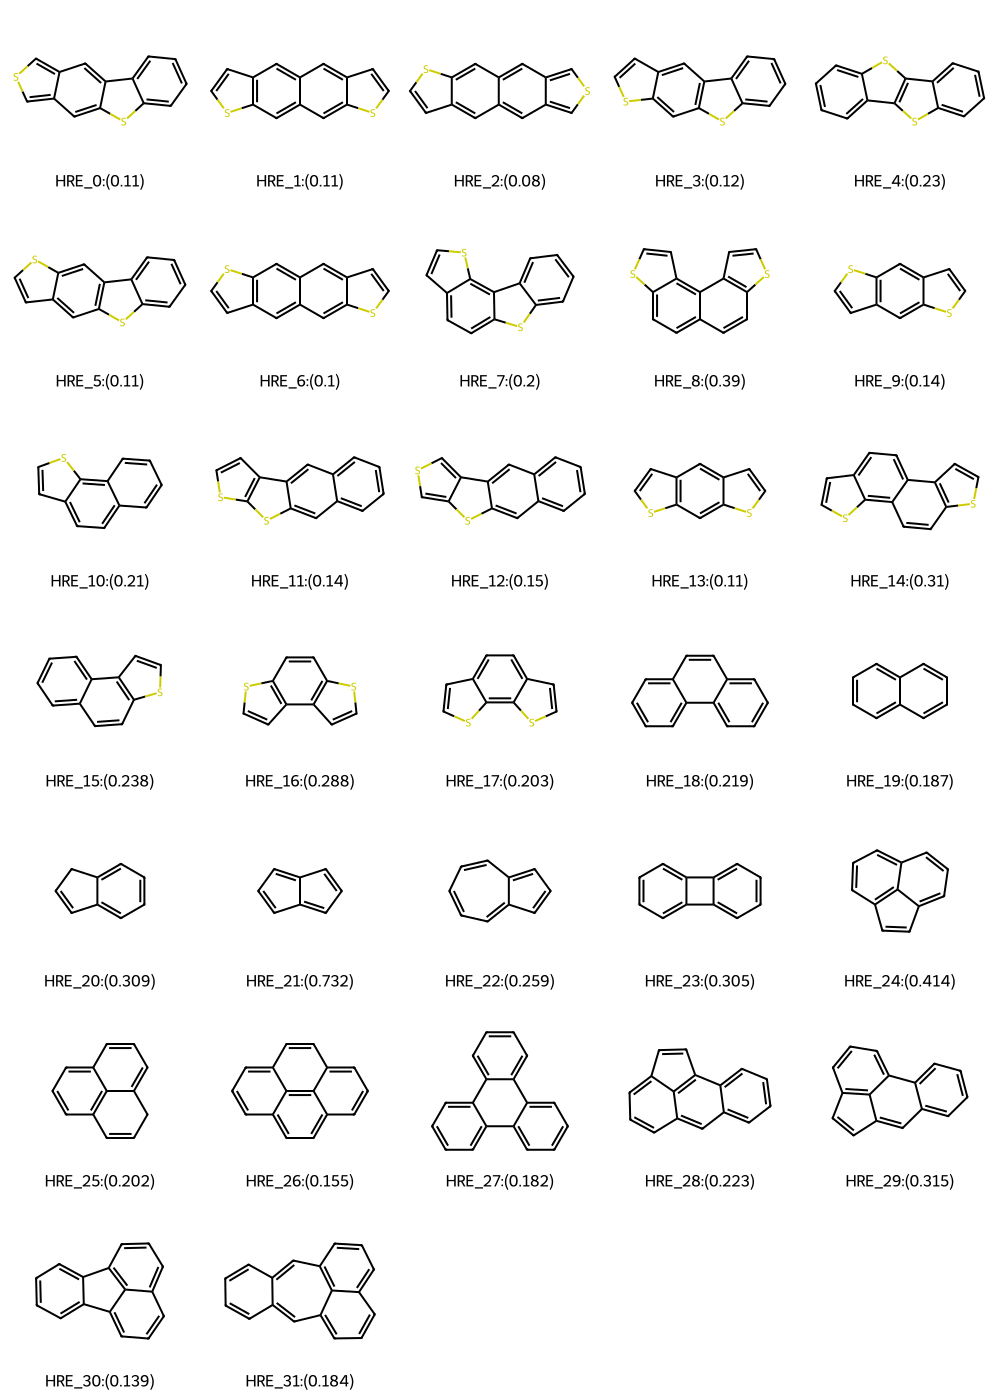

In [69]:
df_4_rings = pd.concat([df_heteros[df_heteros['rings']<=4.1], df_acenes[df_acenes['rings']<=4.1]], ignore_index=True)
print(len(df_4_rings))
mols = [Chem.MolFromSmiles(s) for s in df_4_rings['SMILES'].values]
hre_list = [round(i,3) for i in list(df_4_rings['HRE'].values)]
labels = [f"HRE_{i}:({hre_list[i]})" for i in range(len(df_4_rings))]
img = Draw.MolsToGridImage(mols[:50], molsPerRow=5, subImgSize=(200,200), legends=labels)
img

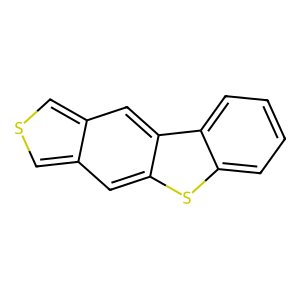

In [70]:
# Example usage
smiles = list(df_4_rings['SMILES'].values)[0]
hre = list(df_4_rings['HRE'].values)[0]

mol = Chem.MolFromSmiles(smiles)
img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300))
img

In [80]:
def smiles_to_ptcfm(smiles, energy):
    mol = Chem.MolFromSmiles(smiles)

    # Atom codes → one-hot
    atom_types = ["C", "S"]
    x = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 6: code = 0   # Carbon
        elif atom.GetAtomicNum() == 16: code = 1 # Sulfur
        # else: code = 0                          # fallback
        one_hot = [0]*len(atom_types)
        one_hot[code] = 1
        x.append(one_hot)
    x = torch.tensor(x, dtype=torch.float)

    # Connectivity + same dummy edge_attr for all edges
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [(i, j), (j, i)]
        edge_attr += [[1], [1]]   # identical feature for every edge
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    y = torch.tensor([float(energy)], dtype=torch.float)

    return Data(edge_index=edge_index, x=x, edge_attr=edge_attr, y=y)

In [81]:
class SMILESDataset(InMemoryDataset):
    def __init__(self, smiles_list, energies, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        graphs = [smiles_to_ptcfm(s, e) for s, e in zip(smiles_list, energies)]
        self.data, self.slices = self.collate(graphs)

    def get(self, idx):
        return super().get(idx)

In [82]:
dataset = SMILESDataset(smiles_list=df_4_rings['SMILES'], energies=df_4_rings['HRE'])

In [83]:
dataset[0].y

tensor([0.1100])

In [ ]:
import qek.data.graphs as qek_graphs
from pathlib import Path
import qek.data.extractors as qek_extractors

compiler = qek_graphs.PTCFMCompiler()

# Use the Qutip Extractor.
extractor = qek_extractors.QutipExtractor(
    path=Path("mol_datasets/processed/saved_data.json"), # save the data
    compiler=compiler
)
extractor.add_graphs(graphs=dataset)
compiled = extractor.compile()
display("Compiled %s sequences" % (len(compiled), ))

imported 32 graphs


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, pr

'Compiled 32 sequences'

In [ ]:
# On our test computer, the practical limit is around 10 qubits - according to Pasqal
# do not set the max_qubits above 16. The terminal is automatically killed due to computational overheads

max_qubits = 16
processed_dataset = extractor.run(max_qubits=max_qubits).processed_data

# it does not seem to take our target values
# moreover, the extractor is designed to handle molecules with four rings

display("Extracted features from %s samples"% (len(processed_dataset), ))

Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (33 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (20 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (19 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (27 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (30 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (32 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (24 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (23 > 16),

/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:552: UserWarning: Register serialization to an abstract representation irreversibly converts all qubit ID's to strings.
  names = stringify_qubit_ids(self._ids)


processed data saved to mol_datasets/processed/saved_data.json


'Extracted features from 18 samples'

In [79]:
for pd, label in zip(processed_dataset, df_4_rings['HRE'].values):
    pd.target = label

processed_dataset[0].target

0.11

Graph 0


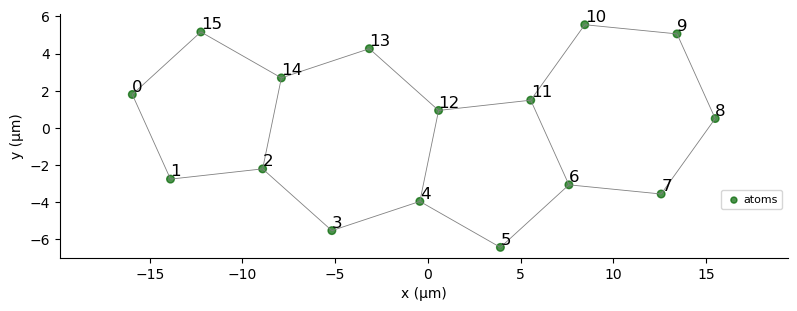

Graph 1


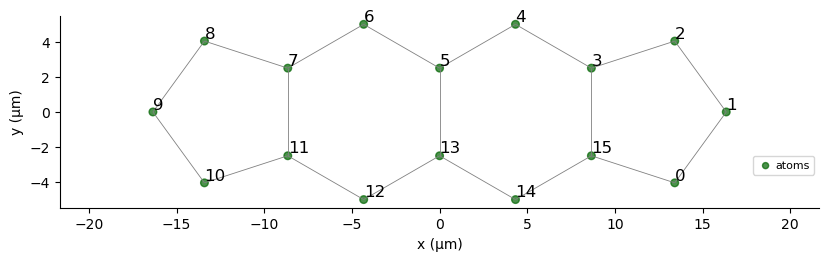

Graph 2


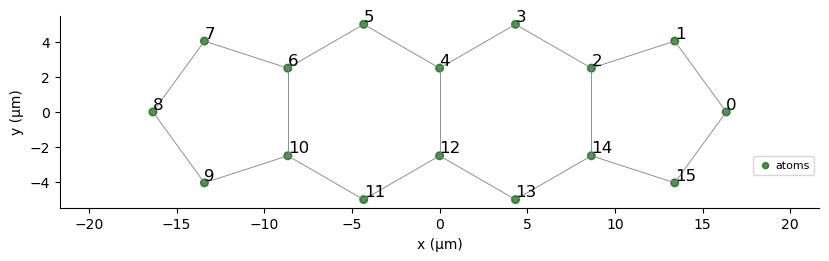

Graph 3


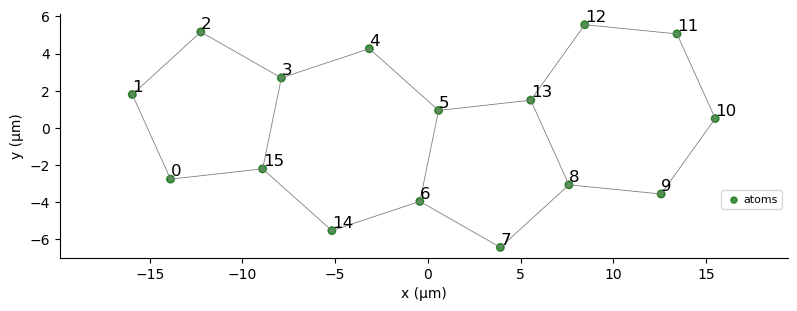

Graph 4


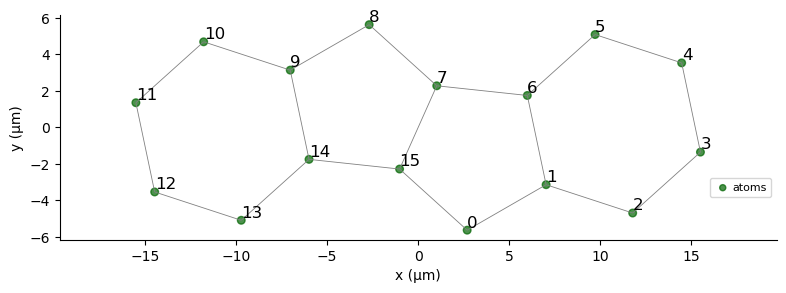

Graph 5


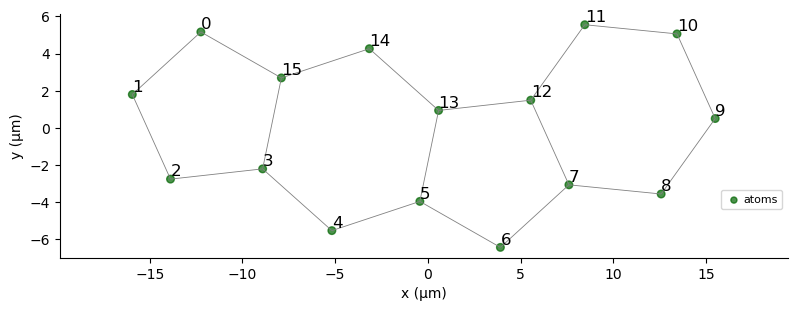

Graph 6


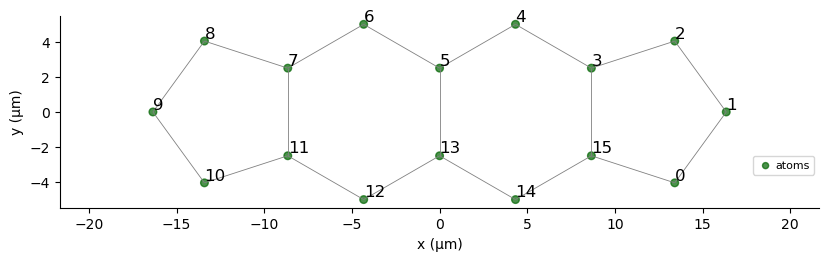

Graph 7


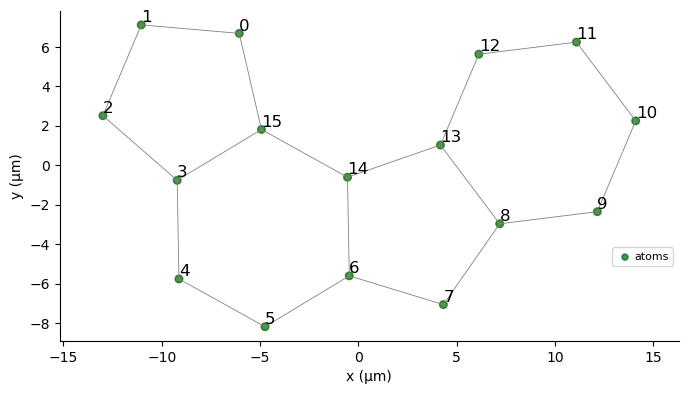

Graph 8


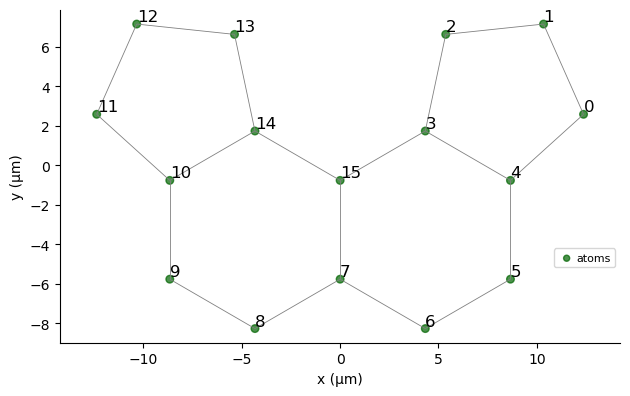

Graph 9


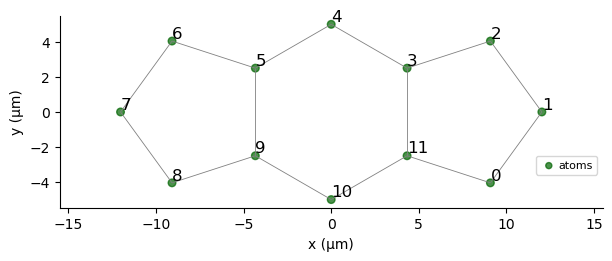

Graph 10


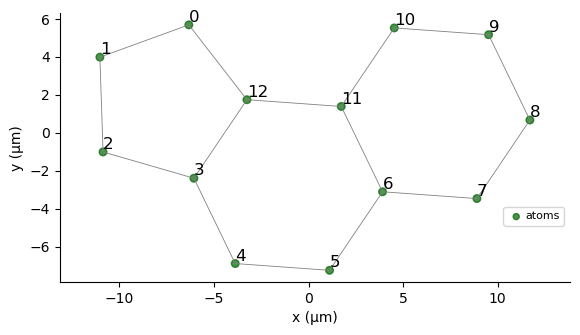

Graph 11


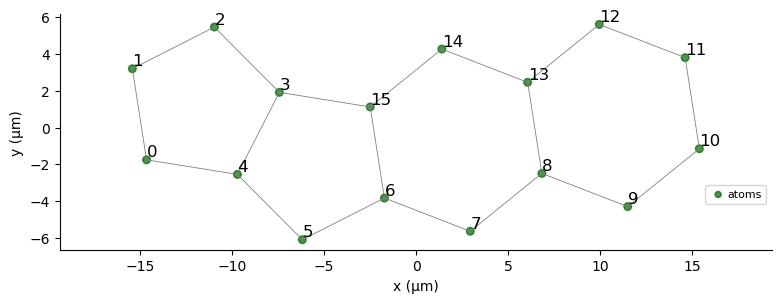

Graph 12


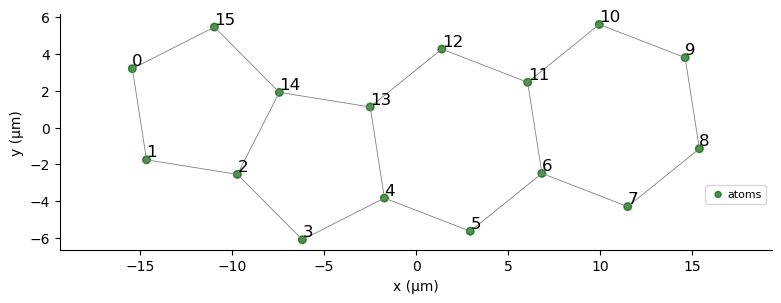

Graph 13


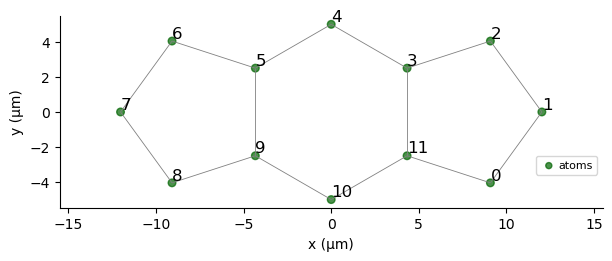

Graph 14


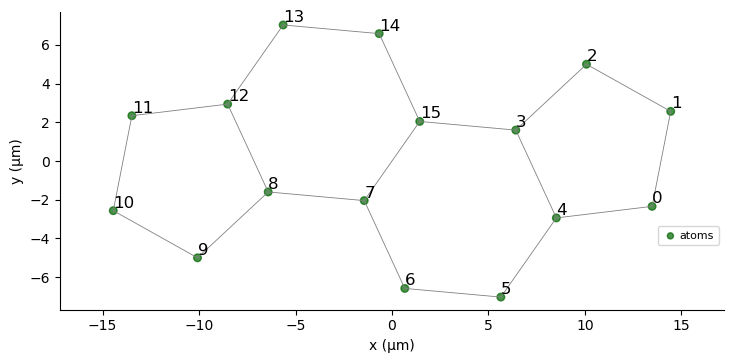

Graph 15


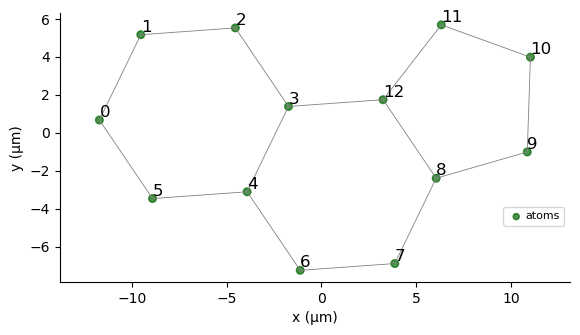

Graph 16


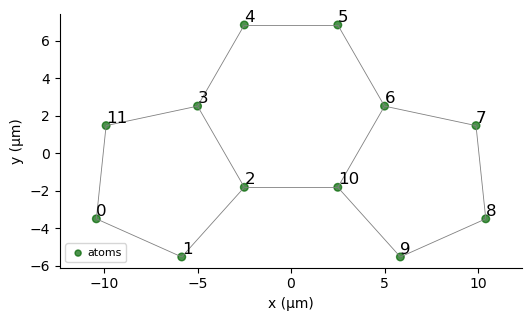

Graph 17


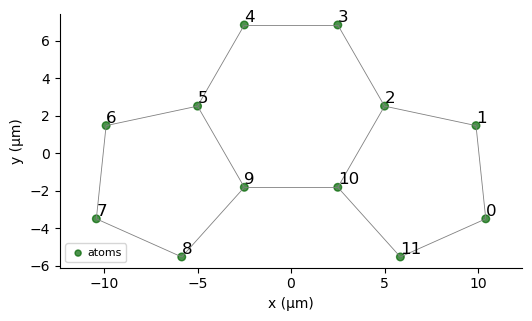

In [84]:
# Loop through all graphs in the dataset - less than five rings
for i, example in enumerate(processed_dataset):
    print(f"Graph {i}")
    example.draw_register()

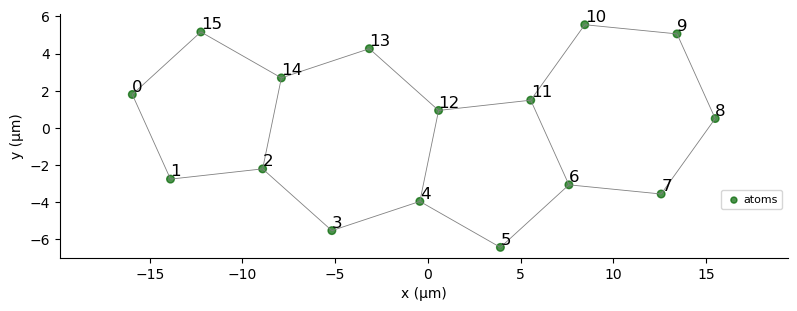

In [27]:
example = processed_dataset[0]
example.draw_register()

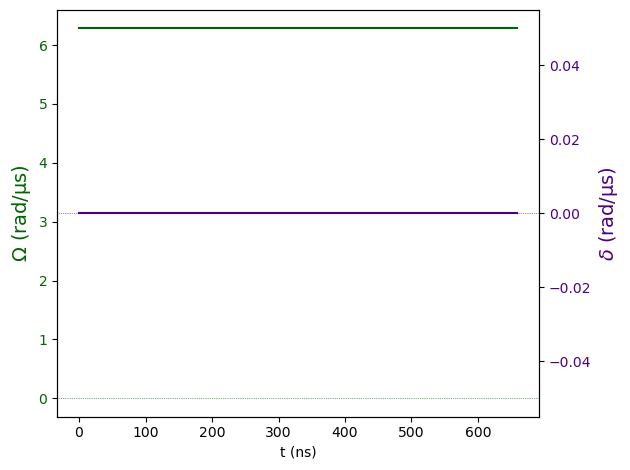

In [28]:
example.draw_pulse()

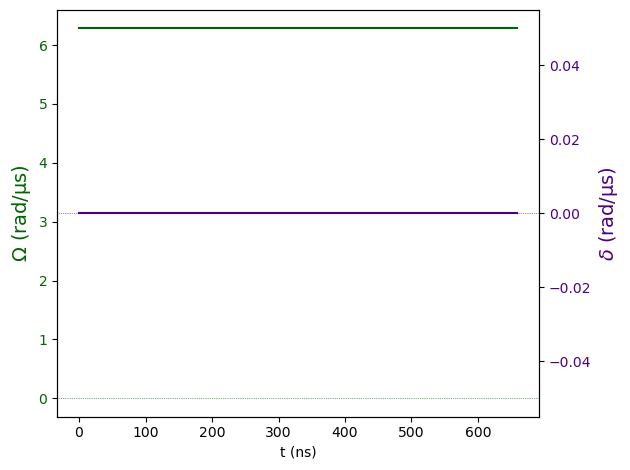

In [ ]:
processed_dataset[1].draw_pulse() # same purses for all graphs?

In [33]:
display(example.state_dict)
print(f"Total number of samples: {sum(example.state_dict.values())}")

{'0000000000000010': 11,
 '0001010000010010': 1,
 '0000000000000000': 108,
 '0000001000100100': 1,
 '0010000000000000': 8,
 '0000000000001001': 7,
 '0000100100100000': 3,
 '0000010000000001': 6,
 '1001010000000010': 1,
 '0000100000000100': 15,
 '0000000100100010': 2,
 '0000000010101000': 2,
 '0000000010100010': 4,
 '0000001010001001': 1,
 '0000100000010001': 2,
 '0000100000000001': 7,
 '1001000000000000': 12,
 '1000000000000100': 2,
 '0010000010010001': 3,
 '0000000100001000': 10,
 '0000000010001000': 3,
 '0000010010000000': 2,
 '0000000010000000': 12,
 '0010000000000010': 5,
 '0010001000010000': 5,
 '0000100100000000': 10,
 '0001001000000010': 2,
 '0000101000000101': 1,
 '0000001000010000': 9,
 '0000100010001000': 3,
 '0000000100100000': 14,
 '0010000010101010': 2,
 '1001000100001000': 2,
 '0000010000000010': 8,
 '0000010000001010': 3,
 '0000001000000100': 5,
 '0000010010100000': 1,
 '0001000000000000': 18,
 '0000000010010000': 12,
 '0000000000010000': 10,
 '1001000000001000': 5,
 '10

Total number of samples: 1000


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


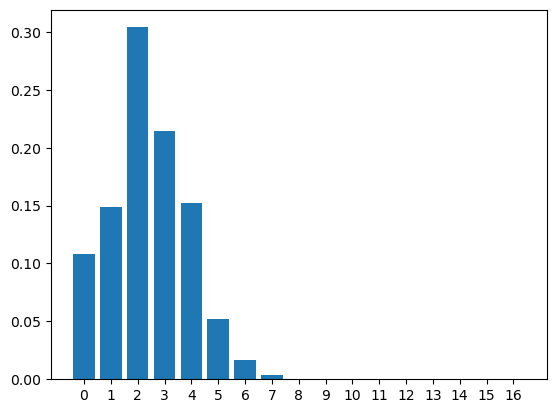

In [34]:
example.draw_excitation()

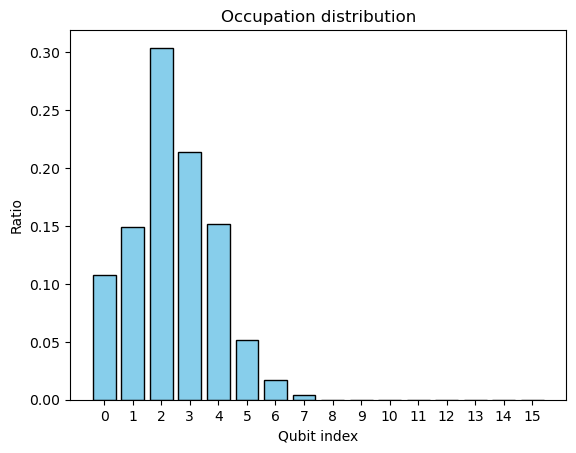

In [35]:
dist_excitation = np.zeros(max_qubits, dtype=int)

for state, weight in example.state_dict.items():
    num_up = state.count('1')
    dist_excitation[num_up] += weight

ratios = dist_excitation / dist_excitation.sum()

plt.bar(range(max_qubits), ratios, color="skyblue", edgecolor="black")
plt.xticks(range(16))
plt.xlabel("Qubit index")
plt.ylabel("Ratio")
plt.title('Occupation distribution')
plt.show()

In [140]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from qek.kernel import QuantumEvolutionKernel as QEK
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

Kernel-based regression

In [135]:
X = [data for data in processed_dataset]  
y = [data.target for data in processed_dataset] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # remove stratify argument for regression

In [ ]:
X = [data for data in processed_dataset]  
y = [data.target for data in processed_dataset] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # remove stratify argument for regression

qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

In [136]:
qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.013973105963721968
MAE: 0.10738522955141543
R²: 0.04944857389646484


In [ ]:
# cross validation
qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)

cv = KFold(n_splits=3, shuffle=True, random_state=42)
mse_scores = cross_val_score(model, X, y, cv=cv,
                             scoring=make_scorer(mean_squared_error))
mae_scores = cross_val_score(model, X, y, cv=cv,
                             scoring=make_scorer(mean_absolute_error))
r2_scores  = cross_val_score(model, X, y, cv=cv,
                             scoring=make_scorer(r2_score))

print("Cross‑validated MSE:", np.mean(mse_scores))
print("Cross‑validated MAE:", np.mean(mae_scores))
print("Cross‑validated R²:", np.mean(r2_scores))

Cross‑validated MSE: 0.006773286222759558
Cross‑validated MAE: 0.06910144398656018
Cross‑validated R²: -0.00618265737345521


Hard to evaluate the model due to the small number of test samples

In [107]:
X_train[0].dist_excitation()

array([0.076, 0.148, 0.271, 0.271, 0.147, 0.064, 0.018, 0.005, 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [109]:
from scipy.spatial.distance import jensenshannon

max_size = max(len(data.dist_excitation()) for data in processed_dataset)
distributions = [data.dist_excitation(size=max_size) for data in processed_dataset]
y = np.array([data.target for data in processed_dataset])

# Pairwise JSD distances
n = len(distributions)
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = jensenshannon(distributions[i], distributions[j])

# Convert to similarity (kernel) matrix
similarity_matrix = 1 - distance_matrix

In [111]:
similarity_matrix.shape

(18, 18)

In [ ]:
# Train/test split
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.4, random_state=42)

# Extract submatrices for training and testing
K_train = similarity_matrix[np.ix_(train_idx, train_idx)]
K_test = similarity_matrix[np.ix_(test_idx, train_idx)]

y_train, y_test = y[train_idx], y[test_idx]

# SVR with precomputed kernel
svr = SVR(kernel="precomputed")
svr.fit(K_train, y_train)
y_pred = svr.predict(K_test)

print("SVR with JSD kernel")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


SVR with JSD kernel
MSE: 0.008893862250178427
MAE: 0.0849475893920886
R²: 0.13398834390411662


In [127]:
from sklearn.manifold import MDS
from sklearn.ensemble import RandomForestRegressor

# Embed distance matrix into Euclidean space
embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_embedded = embedding.fit_transform(distance_matrix)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_embedded, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest with JSD embedding")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest with JSD embedding
MSE: 0.005287054449806959
MAE: 0.05001835521000002
R²: 0.6403364319859212


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


w/ cross validation

In [ ]:
# w/ cross validation
rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers
mse_scorer = make_scorer(mean_squared_error)
mae_scorer = make_scorer(mean_absolute_error)
r2_scorer  = make_scorer(r2_score)

# Evaluate with cross-validation
mse_scores = cross_val_score(rf, X_embedded, y, cv=cv, scoring=mse_scorer)
mae_scores = cross_val_score(rf, X_embedded, y, cv=cv, scoring=mae_scorer)
r2_scores  = cross_val_score(rf, X_embedded, y, cv=cv, scoring=r2_scorer)

print("Random Forest with JSD embedding (cross‑validation)")
print("Mean MSE:", mse_scores.mean())
print("Mean MAE:", mae_scores.mean())
print("Mean R²:", r2_scores.mean())

Random Forest with JSD embedding (cross‑validation)
Mean MSE: 0.00468491260724904
Mean MAE: 0.05442975363
Mean R²: -1.140636316455582
